- first trial run of separate FC (10 M dataset)

# Setup

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799


# Processing h5 data

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:
# idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_FC.npz"
# test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

In [9]:
# data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5"
# h5_file_new_geo = h5py.File(data_path_new_geo, "r")

data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [10]:
# idxs_path_new_geo_e = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/e_FC.npz"
# test_idxs_new_geo_e  = np.load(idxs_path_new_geo_e, allow_pickle=True)['test_idxs']

# idxs_path_new_geo_mu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/mu_FC.npz"
# test_idxs_new_geo_mu  = np.load(idxs_path_new_geo_mu, allow_pickle=True)['test_idxs']

# idxs_path_new_geo_emu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_FC.npz"
# test_idxs_new_geo_emu  = np.load(idxs_path_new_geo_emu, allow_pickle=True)['test_idxs']

# idxs_path_new_geo_emu_all = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz"
# test_idxs_new_geo_emu_all  = np.load(idxs_path_new_geo_emu_all, allow_pickle=True)['test_idxs']

idxs_path_new_geo_e = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/e_FC.npz"
test_idxs_new_geo_e  = np.load(idxs_path_new_geo_e, allow_pickle=True)['test_idxs']

idxs_path_new_geo_mu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/mu_FC.npz"
test_idxs_new_geo_mu  = np.load(idxs_path_new_geo_mu, allow_pickle=True)['test_idxs']

# idxs_path_new_geo_emu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_FC.npz"
# test_idxs_new_geo_emu  = np.load(idxs_path_new_geo_emu, allow_pickle=True)['test_idxs']

idxs_path_new_geo_emu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_ALL.npz"
test_idxs_new_geo_emu  = np.load(idxs_path_new_geo_emu, allow_pickle=True)['test_idxs']

# data_new_geo_e = get_values(h5_file_new_geo, test_idxs_new_geo_e)
# data_new_geo_mu = get_values(h5_file_new_geo, test_idxs_new_geo_mu)
# data_new_geo_emu = get_values(h5_file_new_geo, test_idxs_new_geo_emu)
# data_new_geo_emu_all = get_values(h5_file_new_geo, test_idxs_new_geo_emu_all)

# h5_event_ids_e = data_new_geo_e['event_ids']
# h5_event_ids_mu = data_new_geo_mu['event_ids']
# h5_event_ids_emu = data_new_geo_emu['event_ids']
# h5_event_ids_emu_all = data_new_geo_emu_all['event_ids']

# h5_cuts_e = get_cut_start_idxs(h5_event_ids_e)
# h5_cuts_mu = get_cut_start_idxs(h5_event_ids_mu)
# h5_cuts_emu = get_cut_start_idxs(h5_event_ids_emu)
# h5_cuts_emu_all = get_cut_start_idxs(h5_event_ids_emu_all)

# print("fq cuts:", len(fq_cuts), fq_cuts[:10], fq_cuts[-3:])
# print("h5 cuts:", len(h5_cuts_e), h5_cuts_e[:10], h5_cuts_e[-3:])
# print("h5 cuts:", len(h5_cuts_mu), h5_cuts_mu[:10], h5_cuts_mu[-3:])
# print("h5 cuts:", len(h5_cuts_emu), h5_cuts_emu[:10], h5_cuts_emu[-3:])
# print("h5 cuts:", len(h5_cuts_emu_all), h5_cuts_emu_all[:10], h5_cuts_emu_all[-3:])

In [11]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [12]:
data_new_geo_emu = get_values(h5_file_new_geo, test_idxs_new_geo_emu)
data_new_geo_mu =  get_values(h5_file_new_geo, test_idxs_new_geo_mu)
data_new_geo_e =  get_values(h5_file_new_geo, test_idxs_new_geo_e)

# Processing fitQun data

In [13]:
# def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
#     N = len(all_event_ids)
#     cut_start_idxs: list[int] = [0]
#     CUTOFF = 500
#     for i in range(N - 1):
#         if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
#             cut_start_idxs.append(i+ 1)
#     cut_start_idxs.append(len(all_event_ids)-1)
#     return cut_start_idxs

# def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
#     missing_ids_fq = []
#     missing_inds_fq = []
#     missing_ids_h5 = []    
#     missing_inds_h5 = []
#     n_cuts = len(fq_cuts)
#     assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
#     for i in range(1, n_cuts):
#         fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
#         h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

#         fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
#         h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

#         assert fq_ids[0] < 100
#         assert fq_ids[-1] > 990

#         missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
#         if len(missing_both) > 0:
#             print(missing_both)

#         missing_fq = np.setdiff1d(fq_ids, h5_ids)
#         inds_fq = np.searchsorted(fq_ids, missing_fq)

#         missing_ids_fq.append(missing_fq.tolist())
#         missing_inds_fq.append(fq_start_idx + inds_fq)


#         missing_h5 = np.setdiff1d(h5_ids, fq_ids)
#         inds_h5 = np.searchsorted(h5_ids, missing_h5)

#         missing_ids_h5.append(missing_h5.tolist())
#         missing_inds_h5.append(h5_start_idx + inds_h5)
    
#     return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [14]:
# # fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# # fq = FiTQunOutput(fitqun_files_full)

# fitqun_files_mu = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_mu-_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_mu)

In [15]:
# #Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
# fq_event_ids = fq.chain['nevt'] #.compute()
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo_emu['event_ids']

# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)

# print("fq cuts:", len(fq_cuts), fq_cuts[:10], fq_cuts[-3:])
# print("h5 cuts:", len(h5_cuts), h5_cuts[:10], h5_cuts[-3:])

# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))


# # for fc no missing indices so should just use the original one directional code

In [16]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo_emu['event_ids'])), missing_indices_h5)

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo_emu['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo_emu['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [17]:
# h5_electron_flag = fq.electron_flag
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
# h5_muon_flag = fq.muon_flag#.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# fc_cut = data_new_geo_emu['fc'][h5_keep_idx]
# mu_cut = data_new_geo_emu['labels'][h5_keep_idx]==2
# el_cut = data_new_geo_emu['labels'][h5_keep_idx]==1

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [18]:
# mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# fq_mu_nll = mu_mu - el_mu
# fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [19]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [20]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo_mu = apply_cuts(data_new_geo_mu)
cuts_new_geo_e = apply_cuts(data_new_geo_e)

In [21]:
e_idxs_new_geo = data_new_geo_e['labels']==1
mu_idxs_new_geo = data_new_geo_mu['labels']==2

In [22]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [23]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo_e, 1, cuts_new_geo_e)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo_mu, 2, cuts_new_geo_mu)

In [24]:
resnet_args = {'linestyle':"-"}
electron_args_new_geo = {'indices':test_idxs_new_geo_e[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo_mu[mu_idxs_new_geo],'selection':mu_cuts} # still selection for the physical cuts

#muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts} # trying to convert “muon rows inside the test subset” into “global H5 row indices” for the output dir

# Loading ResNet results

In [25]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/regression/"

In [26]:
# cuts_new_geo_emu = apply_cuts(data_new_geo_emu)
# e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo_emu, 1, cuts_new_geo_emu)
# mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo_emu, 2, cuts_new_geo_emu)

In [27]:
# # output_energy = "2026-02-05/18-30-30"
# # output_pos = "2026-02-05/21-17-54"
# # output_dir = ""

# output_pos_mu = 'muons/position/2026-02-12/17-14-12/'
# output_pos_e = 'electrons/position/2026-02-12/10-36-01/'

# output_dir_mu = 'muons/directions/2026-02-12/16-11-11/'
# output_dir_e = 'electrons/directions/2026-02-12/11-27-55/'


output_pos_mu = 'muons/position/2026-02-17/11-01-24/'
output_pos_e = 'electrons/position/2026-02-17/11-00-22/'



output_dir_mu = 'muons/directions/2026-02-17/11-30-33/'
output_dir_e = 'electrons/directions/2026-02-17/11-29-33/'

# output_energy_mu = 'muons/energy/2026-02-12/18-14-04/'

output_energy_mu = 'muons/energy/2026-02-17/00-01-04/'

# output_energy_e = 'electrons/energy/2026-02-12/14-24-01/'

output_energy_e = 'electrons/energy/2026-02-17/11-51-58/'




resnet_muon_position = [ # "ResNet50 QT+mPMT_pos
    WatChMaLPositionRegression(outdir_reg+output_pos_mu, "ResNet50 Muon Position", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
]
resnet_e_position =  [
    WatChMaLPositionRegression(outdir_reg+output_pos_e, "ResNet50 Electron Position", e_pos, e_dir, **electron_args_new_geo, **resnet_args)
]


resnet_muon_direction = [WatChMaLDirectionRegression(outdir_reg+output_dir_mu, "ResNet 50 Muon Direction", mu_dir, **muon_args_new_geo, **resnet_args)
]
resnet_e_direction = [WatChMaLDirectionRegression(outdir_reg+output_dir_e, "ResNet50 Electron Direction", e_dir, **electron_args_new_geo, **resnet_args)]


resnet_muon_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_energy_mu, "ResNet 50 Muon Energy", mu_mom,2, **muon_args_new_geo, **resnet_args)
]
resnet_e_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_energy_e, "ResNet 50 Electron Energy", e_mom, 1, **electron_args_new_geo, **resnet_args)
]


In [28]:
# outdir_reg = '/vols/hyperk/users/ks2922/ML_2025/cds_geometry/outputs/regression'
# resnet_muon_position = [
#     WatChMaLPositionRegression(outdir_reg+"/positions/2026-02-11/17-28-03", "CDS geo DC $\mu$-", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
# ]

# resnet_muon_direction = [
#     WatChMaLDirectionRegression(outdir_reg+"/directions/2026-02-11/17-27-25", "CDS geo DC $\mu$-", mu_dir, **muon_args_new_geo, **resnet_args)
# ]

# resnet_muon_energy = [
#     WatChMaLEnergyRegression(outdir_reg+"/energies/2026-02-11/17-29-00", "CDS geo DC $\mu$-", mu_mom, 2, **muon_args_new_geo, **resnet_args)
# ]

# resnet_electron_position = [
#     WatChMaLPositionRegression(outdir_reg+"/positions/2026-02-11/17-27-45", "CDS geo DC $e$-", e_pos, e_dir, **electron_args_new_geo, **resnet_args)
# ]

# resnet_electron_direction = [
#     WatChMaLDirectionRegression(outdir_reg+"/directions/2026-02-13/14-44-05", "CDS geo DC $e$-", e_dir, **electron_args_new_geo, **resnet_args)
# ]

# resnet_electron_energy = [
#     WatChMaLEnergyRegression(outdir_reg+"/energies/2026-02-11/17-28-40", "CDS geo DC $e$-", e_mom, 1, **electron_args_new_geo, **resnet_args)
# ]

# Plot training progression

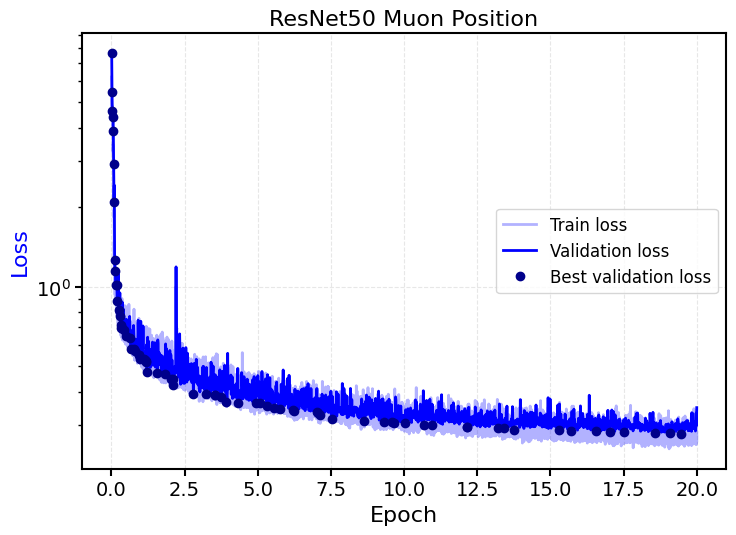

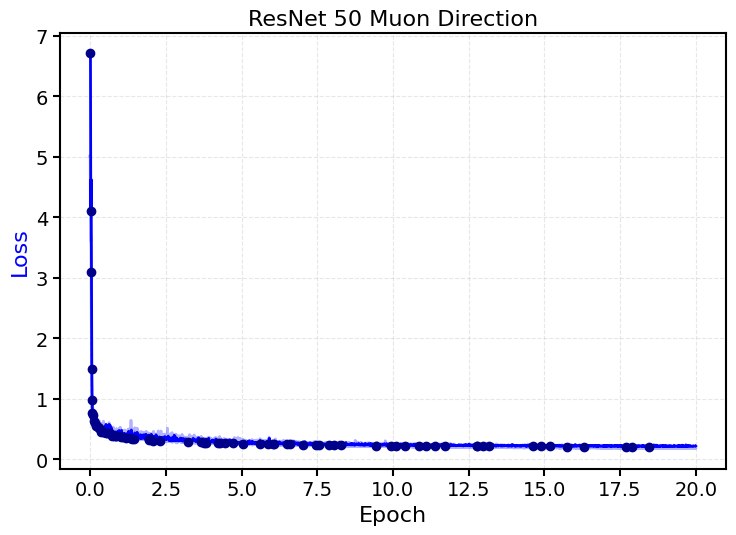

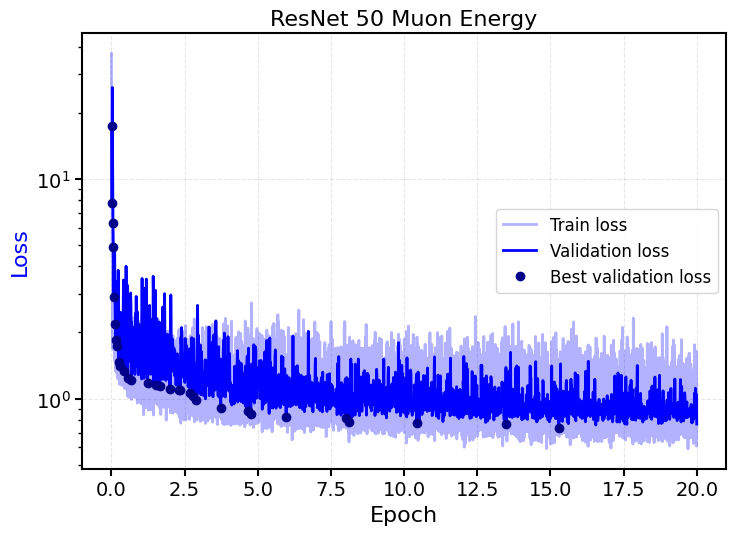

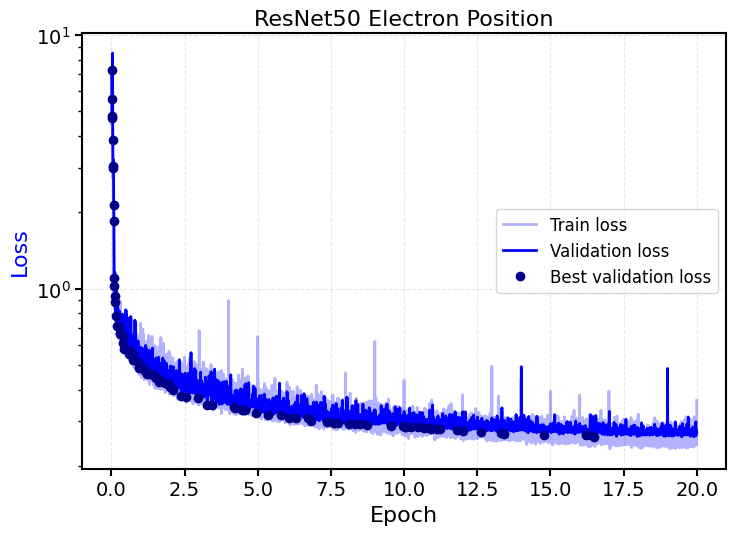

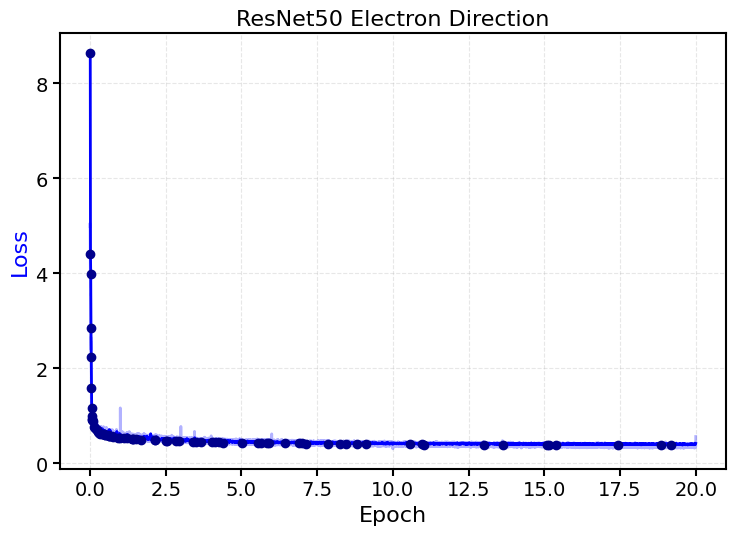

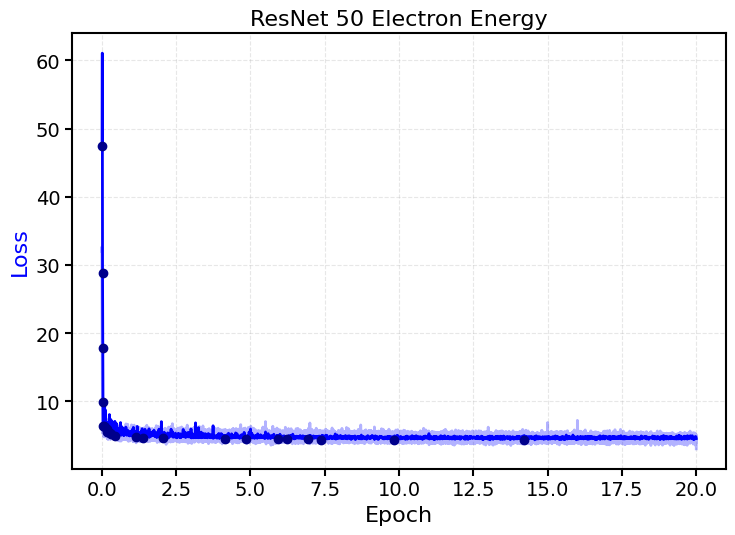

In [29]:
for r in resnet_muon_position:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')
for r in resnet_muon_direction:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_muon_energy:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')

# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_position:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_e_position:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')
for r in resnet_e_direction:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_e_energy:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

# Statistics

In [30]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']

tabulate_statistics(resnet_muon_position, position_stats, position_stat_labels, position_stat_types)


# when ran together, these were better? -- need to check this

,ResNet50 Muon Position
x position resolution [cm],3.05
y position resolution [cm],3.01
z position resolution [cm],3.09
3D position resolution [cm],5.82
Transverse position resolution [cm],4.97
Longitudinal position resolution [cm],2.61
Longitudinal position mean bias [cm],-0.03


In [31]:
tabulate_statistics(resnet_e_position, position_stats, position_stat_labels, position_stat_types)

,ResNet50 Electron Position
x position resolution [cm],3.08
y position resolution [cm],3.05
z position resolution [cm],3.13
3D position resolution [cm],5.86
Transverse position resolution [cm],4.06
Longitudinal position resolution [cm],3.83
Longitudinal position mean bias [cm],0.76


In [32]:
#hostname
energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', 'energy_percentage_errors', 'momentum_percentage_errors','energy_percentage_errors', 'momentum_percentage_errors']
energy_stat_types = ['resolution', 'resolution', 'mean','mean', 'resolution', 'resolution','mean','mean']

# r = resnet_muon_energy[0]
# valid = np.asarray(r.predictions) >= 105.7

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet 50 Muon Energy
energy_residuals,6.79
momentum_residuals,7.18
energy_residuals,0.27
momentum_residuals,0.31
energy_percentage_errors,1.88
momentum_percentage_errors,2.13
energy_percentage_errors,0.20
momentum_percentage_errors,0.25


In [33]:

# for r in all_runs_mom:
#     x = np.asarray(r.get_quantity("momentum_fractional_errors"))
#     sel = r.selection
#     if sel is not None:
#         x = x[sel]
#     n_total = x.size
#     n_bad = np.sum(~np.isfinite(x))
#     print(f"{r.run_label}: non-finite = {n_bad}/{n_total} ({(n_bad/n_total):.3%})")

# import numpy as np

r = resnet_muon_energy[0] # if it's a list; otherwise r = resnet_muon_energy

# 1) Check raw predictions array
pred = np.asarray(r.predictions)
print("pred shape:", pred.shape)
print("pred non-finite:", np.sum(~np.isfinite(pred)), "/", pred.size)

# 2) Check the quantity you were testing (energy error)
q = np.asarray(r.get_quantity("energy_residuals"))  # or the exact quantity name you're using
sel = r.selection
if sel is not None:
    q = q[sel]
print("energy_errors non-finite:", np.sum(~np.isfinite(q)), "/", q.size)

import numpy as np

r = resnet_muon_energy[0]  # adjust if not list

sel = r.selection
pred_p = np.asarray(r.momentum_prediction)  # or r.momentum_prediction attribute name
pred_E = np.asarray(r.energy_prediction)

t_p = np.asarray(r.true_momenta)
t_E = np.asarray(r.true_energies)

if sel is not None:
    pred_p = pred_p[sel]; pred_E = pred_E[sel]
    t_p = t_p[sel]; t_E = t_E[sel]

print("pred momentum nonfinite:", np.sum(~np.isfinite(pred_p)))
print("pred energy nonfinite:",   np.sum(~np.isfinite(pred_E)))
print("true momentum nonfinite:", np.sum(~np.isfinite(t_p)))
print("true energy nonfinite:",   np.sum(~np.isfinite(t_E)))

mr = np.asarray(r.momentum_residuals)
er = np.asarray(r.energy_residuals)
if sel is not None:
    mr = mr[sel]; er = er[sel]
print("mom residual nonfinite:", np.sum(~np.isfinite(mr)))
print("E residual nonfinite:",   np.sum(~np.isfinite(er)))

Epred = np.asarray(resnet_muon_energy[0].predictions)
print("min predicted energy:", Epred.min())
print("fraction below muon mass:", np.mean(Epred < 105.7))

r = resnet_muon_energy[0]
Epred = np.asarray(r.predictions)
Ttrue = np.asarray(r.true_momenta)  # not kinetic energy; just for comparison you need true_energies
Etrue = np.asarray(r.true_energies)

print("pred min:", Epred.min())
print("fraction pred < m_mu:", np.mean(Epred < 105.7))
print("true energy min:", Etrue.min(), "should be >= 105.7 if it's total energy")

r = resnet_muon_energy[0]
Epred = np.asarray(r.predictions)
print("pred min/max:", Epred.min(), Epred.max())
print("frac pred < 105.7:", np.mean(Epred < 105.7))

import numpy as np

def summarize_energy(r, name):
    E = np.asarray(r.predictions)
    sel = r.selection
    if sel is not None:
        E = E[sel]
    print(name,
          "min", E.min(),
          "p1", np.quantile(E, 0.01),
          "p50", np.quantile(E, 0.5),
          "frac<E_mu", np.mean(E < 105.7))

summarize_energy(resnet_muon_energy[0], "mu-only")

r = resnet_muon_energy[0]
Epred = np.asarray(r.predictions)
sel = r.selection
if sel is not None:
    Epred = Epred[sel]

print("fraction exactly 0:", np.mean(Epred == 0.0))
print("fraction < 1e-6:", np.mean(Epred < 1e-6))
print("unique values (sample):", np.unique(Epred[:1000]).shape)


pred shape: (344021,)
pred non-finite: 0 / 344021
energy_errors non-finite: 0 / 302437
pred momentum nonfinite: 0
pred energy nonfinite: 0
true momentum nonfinite: 0
true energy nonfinite: 0
mom residual nonfinite: 0
E residual nonfinite: 0
min predicted energy: 175.8535919189453
fraction below muon mass: 0.0
pred min: 175.8535919189453
fraction pred < m_mu: 0.0
true energy min: 160.80226113926383 should be >= 105.7 if it's total energy
pred min/max: 175.8535919189453 1157.5103759765625
frac pred < 105.7: 0.0
mu-only min 175.8535919189453 p1 182.7229901123047 p50 359.8467712402344 frac<E_mu 0.0
fraction exactly 0: 0.0
fraction < 1e-6: 0.0
unique values (sample): (1000,)


In [34]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet 50 Electron Energy
energy_residuals,23.01
momentum_residuals,23.01
energy_residuals,-15.88
momentum_residuals,-15.88
energy_percentage_errors,8.69
momentum_percentage_errors,8.70
energy_percentage_errors,-1.91
momentum_percentage_errors,-1.91


In [35]:
# import numpy as np

# # -------------------------------------------------------------------
# # Set these to your electron run object/list
# # Example: resnet_electron_energy or resnet_e_energy etc.
# # -------------------------------------------------------------------
# electron_runs = resnet_e_energy  # <-- change name if needed

# # If it's a single run object, wrap it into a list
# all_runs_e = electron_runs if isinstance(electron_runs, (list, tuple)) else [electron_runs]

# # -------------------------------------------------------------------
# # (Optional) Non-finite check over a quantity for all electron runs
# # -------------------------------------------------------------------
# for r in all_runs_e:
#     x = np.asarray(r.get_quantity("momentum_fractional_errors"))
#     sel = getattr(r, "selection", None)
#     if sel is not None:
#         x = x[sel]
#     n_total = x.size
#     n_bad = np.sum(~np.isfinite(x))
#     print(f"{getattr(r, 'run_label', 'electron_run')}: non-finite = {n_bad}/{n_total} ({(n_bad/n_total):.3%})")

# # -------------------------------------------------------------------
# # Pick one electron run to inspect in detail
# # -------------------------------------------------------------------
# r = all_runs_e[0]

# # 1) Check raw predictions array
# pred = np.asarray(r.predictions)
# sel = getattr(r, "selection", None)
# pred_sel = pred[sel] if sel is not None else pred

# print("pred shape:", pred.shape)
# print("pred (selected) shape:", pred_sel.shape)
# print("pred non-finite:", np.sum(~np.isfinite(pred_sel)), "/", pred_sel.size)

# # 2) Check the quantity you were testing (energy residuals)
# er = np.asarray(r.get_quantity("energy_residuals"))
# er_sel = er[sel] if sel is not None else er
# print("energy_residuals non-finite:", np.sum(~np.isfinite(er_sel)), "/", er_sel.size)

# # -------------------------------------------------------------------
# # Electron-specific sanity checks (replace muon-mass checks)
# # -------------------------------------------------------------------
# # If these attributes exist for your run object:
# pred_p = np.asarray(getattr(r, "momentum_prediction", np.array([])))
# pred_E = np.asarray(getattr(r, "energy_prediction", r.predictions))

# t_p = np.asarray(getattr(r, "true_momenta", np.array([])))
# t_E = np.asarray(getattr(r, "true_energies", np.array([])))

# if sel is not None:
#     if pred_p.size: pred_p = pred_p[sel]
#     pred_E = pred_E[sel]
#     if t_p.size: t_p = t_p[sel]
#     if t_E.size: t_E = t_E[sel]

# if pred_p.size:
#     print("pred momentum nonfinite:", np.sum(~np.isfinite(pred_p)))
# print("pred energy nonfinite:",   np.sum(~np.isfinite(pred_E)))
# if t_p.size:
#     print("true momentum nonfinite:", np.sum(~np.isfinite(t_p)))
# if t_E.size:
#     print("true energy nonfinite:", np.sum(~np.isfinite(t_E)))

# # Residual arrays (if present)
# mr = np.asarray(getattr(r, "momentum_residuals", np.array([])))
# er2 = np.asarray(getattr(r, "energy_residuals", er))
# if sel is not None:
#     if mr.size: mr = mr[sel]
#     er2 = er2[sel]
# if mr.size:
#     print("mom residual nonfinite:", np.sum(~np.isfinite(mr)))
# print("E residual nonfinite:",   np.sum(~np.isfinite(er2)))

# # -------------------------------------------------------------------
# # Look for the "predicting lots of zeros" signature
# # -------------------------------------------------------------------
# Epred = pred_sel  # for energy regression, predictions should be energy

# print("pred min/max:", float(np.min(Epred)), float(np.max(Epred)))
# print("fraction exactly 0:", float(np.mean(Epred == 0.0)))
# print("fraction < 1e-6:",    float(np.mean(Epred < 1e-6)))
# print("unique values (sample):", np.unique(Epred[:1000]).shape)

# def summarize_energy(r_, name):
#     E = np.asarray(r_.predictions)
#     sel_ = getattr(r_, "selection", None)
#     if sel_ is not None:
#         E = E[sel_]
#     print(name,
#           "min", float(np.min(E)),
#           "p1",  float(np.quantile(E, 0.01)),
#           "p50", float(np.quantile(E, 0.50)),
#           "p99", float(np.quantile(E, 0.99)),
#           "frac==0", float(np.mean(E == 0.0)),
#           "frac<1e-6", float(np.mean(E < 1e-6)))

# summarize_energy(r, getattr(r, "run_label", "e-only"))


In [36]:
# Direction statistics

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_direction, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet 50 Muon Direction
Direction residual error,2.10


In [37]:
tabulate_statistics(resnet_e_direction, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet50 Electron Direction
Direction residual error,3.51


# Plots

In [38]:
# print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
# print(len(mu_pos[mu_cuts]))

# A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# print(len(A), len(B))
# print(np.array_equal(A, B))                 # identical set + order
# print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


### Muon Plots

In [39]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

labels = np.asarray(data_new_geo_emu["labels"]).astype(int)

mu_mask = labels == 2

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo_emu["positions"][h5_keep_idx][mu_mask],
#     true_directions=data_new_geo_emu["directions"][h5_keep_idx][mu_mask],
#     true_momenta=data_new_geo_emu["momentum"][h5_keep_idx][mu_mask],
#     true_labels=2,                        
#     indices=fq_keep_idx[mu_mask],       
#     selection=cuts_new_geo_mu,
# )

muon_mom_binning = get_binning(data_new_geo_mu["momentum"], 20, 0, 1000)
muon_cos_zenith_binning = get_binning(np.cos(data_new_geo_mu["angles"][:,0]), 20, -1, 1)

muon_azimuth_binning = get_binning(data_new_geo_mu["angles"][:,1] * 180 / np.pi, 20, -180, 180)

muon_dwall_binning = get_binning(data_new_geo_mu["dwall"], 22, 50, 300)

muon_towall_binning = get_binning(data_new_geo_mu["towall"], 30, 50, 800)

/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1555: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


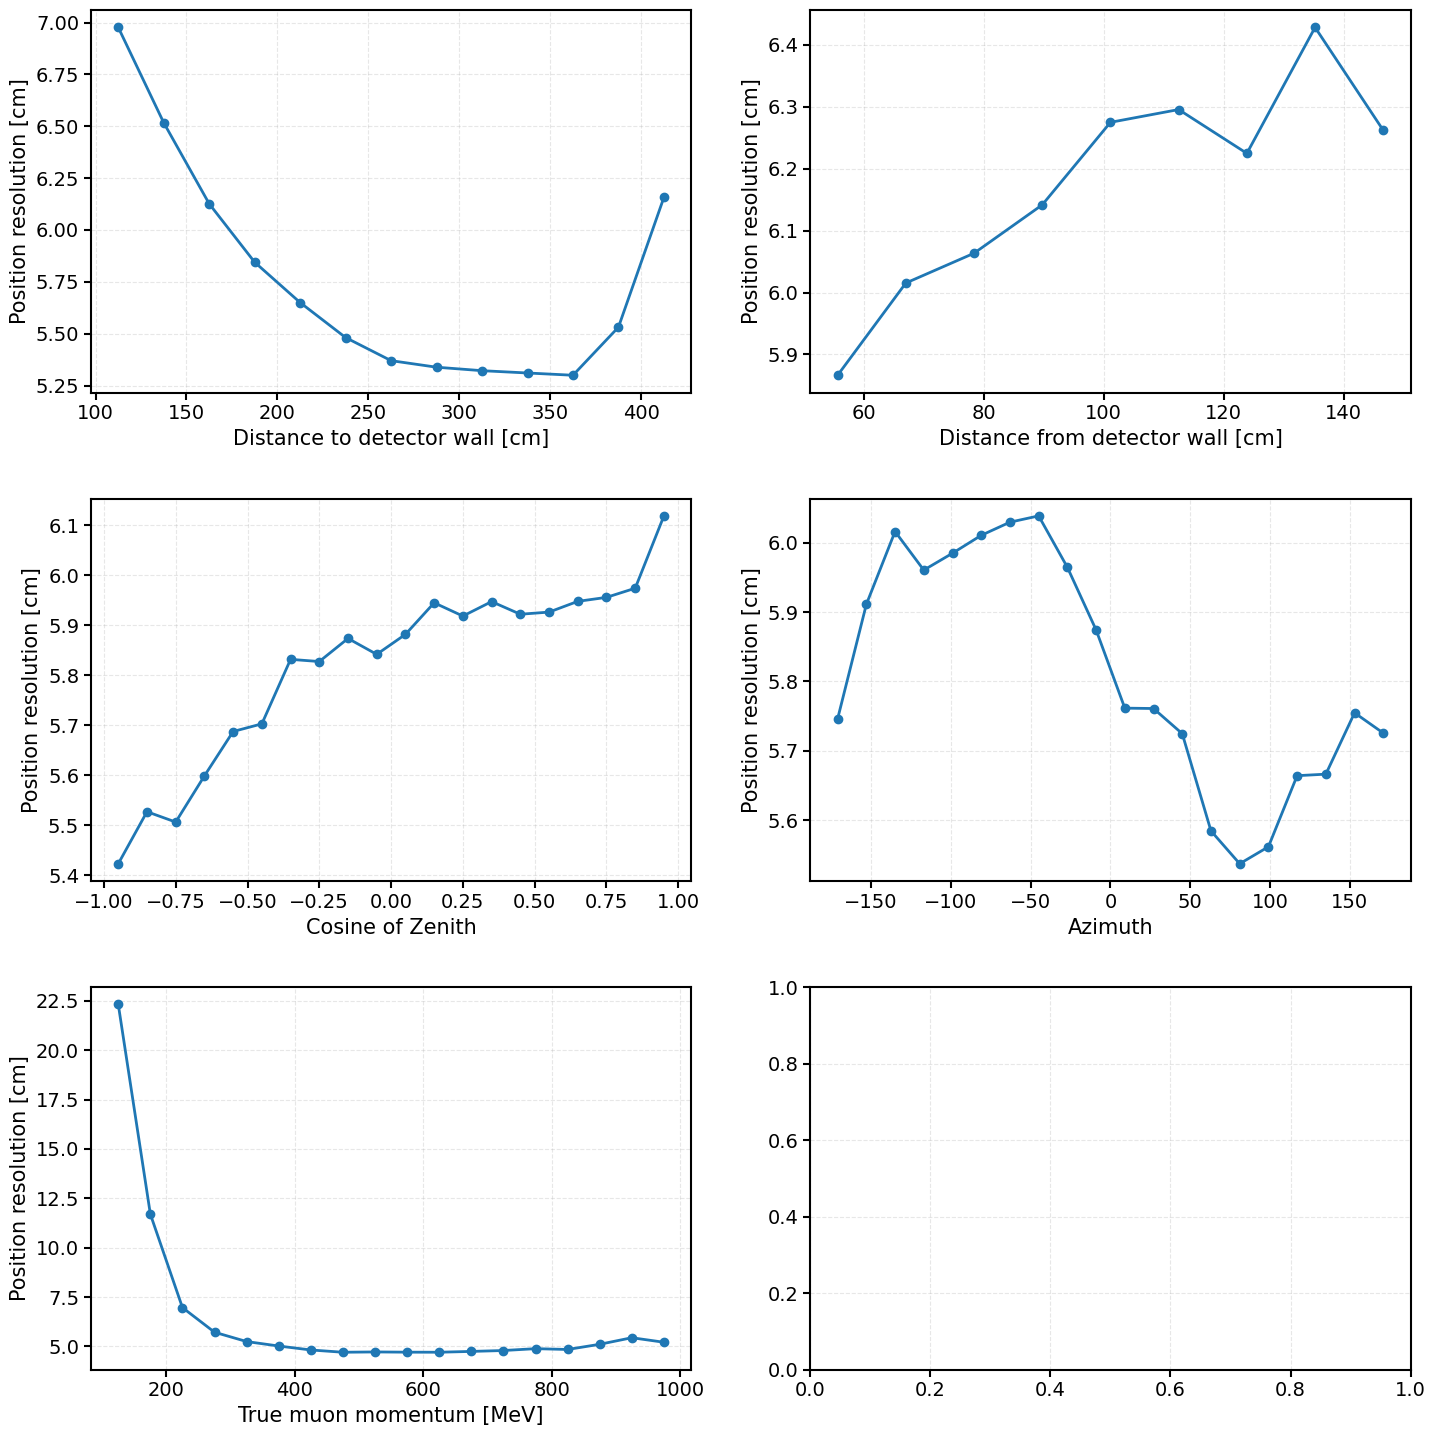

In [40]:
# all_runs_pos = resnet_muon_position + [fitqun_mu]
all_runs_pos = resnet_muon_position

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Position resolution [cm]",legend=None)


NameError: name 'all_runs_mom' is not defined

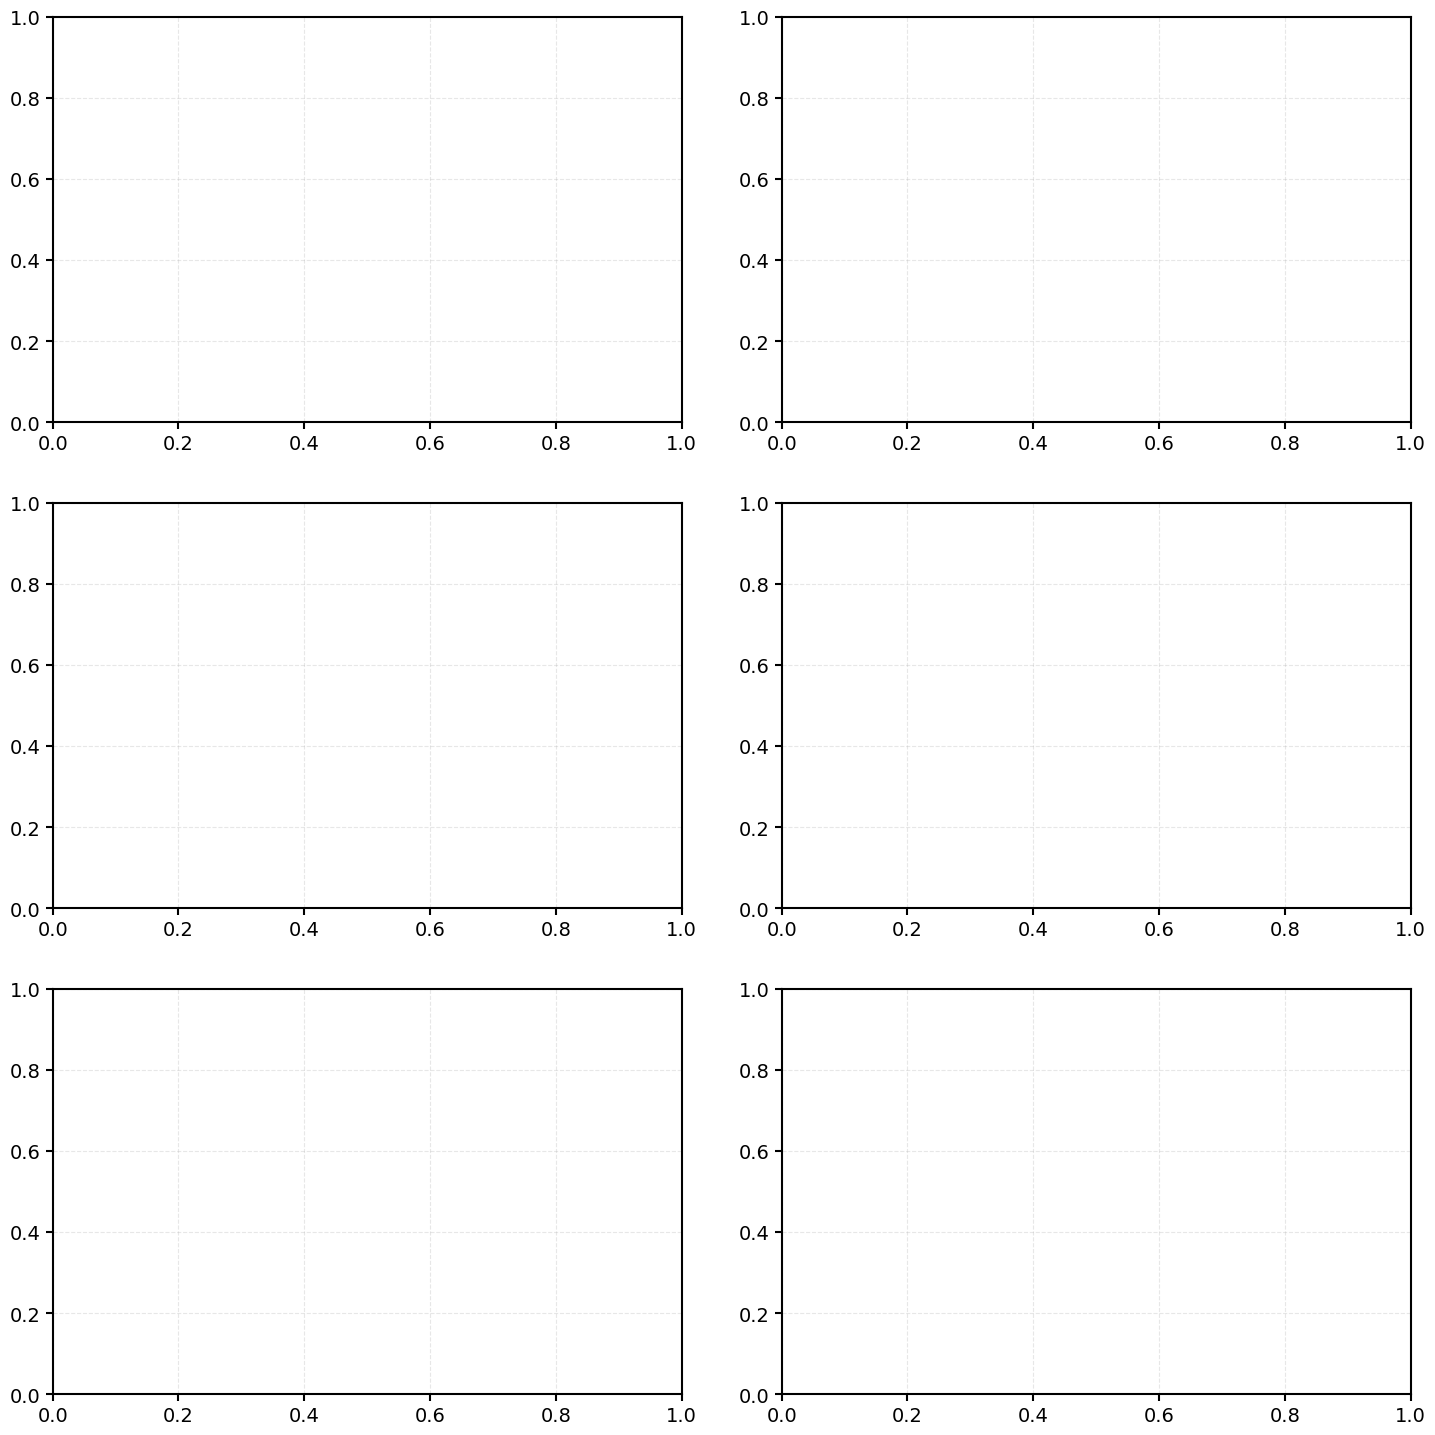

In [41]:
# all_runs_mom =  resnet_muon_energy + [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Momentum resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position Momentum",legend=None)
    plot_resolution_profile([r],'momentum_residuals',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Momentum resolution",legend=None)


In [ ]:
# all_runs_mom =  resnet_muon_direction + [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'direction_errors', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Direction resolution",legend=None)


In [ ]:
e_mask = labels == 1

fitqun_e = FitQun1ParticleFit(
    fq,
    "fiTQun",
    true_positions=data_new_geo_emu["positions"][h5_keep_idx][e_mask],
    true_directions=data_new_geo_emu["directions"][h5_keep_idx][e_mask],
    true_momenta=data_new_geo_emu["momentum"][h5_keep_idx][e_mask],
    true_labels=1,                        
    indices=fq_keep_idx[e_mask],       
    selection=cuts_new_geo_e,
)

e_mom_binning = get_binning(data_new_geo_e["momentum"], 20, 0, 1000)

e_cos_zenith_binning = get_binning(np.cos(data_new_geo_e["angles"][:,0]), 20, -1, 1)

e_azimuth_binning = get_binning(data_new_geo_e["angles"][:,1] * 180 / np.pi, 20, -180, 180)

e_dwall_binning = get_binning(data_new_geo_e["dwall"], 22, 50, 300)

e_towall_binning = get_binning(data_new_geo_e["towall"], 30, 50, 800)

all_runs_pos = resnet_e_position + [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None)

In [ ]:
all_runs_mom =  resnet_e_energy + [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Energy resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Energy resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Energy resolution",legend=None)


In [ ]:
all_runs_dir =  resnet_e_direction + [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)


In [ ]:
## seems like the separate oens are worse?

# also plot more condensed and define as a func maybe